<a href="https://www.kaggle.com/code/ramya18145/notebook-crater-detection?scriptVersionId=314038070" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [6]:
import os, math, random, glob, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

BASE = '/kaggle/working/'

for d in ['tiles', 'patches/crater', 'patches/background', 'labels', 'checkpoints']:
    os.makedirs(f'{BASE}{d}', exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


In [11]:
import os, requests

CATALOGUE_PATH = '/kaggle/working/labels/LROCCraters.csv'

# Force delete and redownload
if os.path.exists(CATALOGUE_PATH):
    os.remove(CATALOGUE_PATH)

CATALOGUE_URL = 'https://raw.githubusercontent.com/silburt/DeepMoon/master/catalogues/LROCCraters.csv'
r = requests.get(CATALOGUE_URL)
print(f'Status: {r.status_code} | Size: {len(r.content)} bytes')

if len(r.content) > 1000:  # make sure it's not empty
    with open(CATALOGUE_PATH, 'wb') as f:
        f.write(r.content)
    print('Saved ✓')
else:
    print('Download failed — file too small, try again')

Status: 200 | Size: 1164643 bytes
Saved ✓


In [12]:
# CATALOGUE_URL = 'https://raw.githubusercontent.com/silburt/DeepMoon/master/catalogues/LROCCraters.csv'
# CATALOGUE_PATH = f'{BASE}labels/LROCCraters.csv'

# if not os.path.exists(CATALOGUE_PATH):
#     r = requests.get(CATALOGUE_URL)
#     with open(CATALOGUE_PATH, 'wb') as f:
#         f.write(r.content)
#     print('Downloaded ✓')

df_raw = pd.read_csv(CATALOGUE_PATH)
df_raw = df_raw.rename(columns={'Lat': 'lat', 'Long': 'lon', 'Diameter (km)': 'diameter_km'})
df = df_raw[df_raw['tag'] == 'standard'][['diameter_km', 'lon', 'lat', 'tag']].reset_index(drop=True)
df.to_csv(f'{BASE}labels/lroc_clean.csv', index=False)

print(f'Clean craters: {len(df)}')

Clean craters: 14914


In [13]:
ZOOM = 7
TILE_SIZE = 256
PATCH_SIZE = 96
BASE_URL = 'https://trek.nasa.gov/tiles/Moon/EQ/LRO_WAC_Mosaic_Global_303ppd_v02/1.0.0/default/default028mm'

def latlon_to_tile(lat, lon, zoom):
    n = 2 ** zoom
    x = int((lon + 180.0) / 360.0 * n)
    y = int((90.0 - lat) / 180.0 * n)
    return max(0, min(x, n-1)), max(0, min(y, n-1))

def latlon_to_pixel(lat, lon, zoom, tile_size=TILE_SIZE):
    n = 2 ** zoom
    x_tile, y_tile = latlon_to_tile(lat, lon, zoom)
    px = int(((lon + 180.0) / 360.0 * n - x_tile) * tile_size)
    py = int(((90.0 - lat) / 180.0 * n - y_tile) * tile_size)
    return x_tile, y_tile, px, py

print('Helpers ready ✓')

Helpers ready ✓


In [17]:
print(f'ZOOM is set to: {ZOOM}')
print(f'PATCH_SIZE is set to: {PATCH_SIZE}')

ZOOM is set to: 7
PATCH_SIZE is set to: 96


In [15]:
needed_tiles = set()
for _, row in df.iterrows():
    x, y = latlon_to_tile(row['lat'], row['lon'], ZOOM)
    needed_tiles.add((x, y))

# Skip already downloaded
needed_tiles = {(x,y) for x,y in needed_tiles
                if not os.path.exists(f'{BASE}tiles/{ZOOM}_{x}_{y}.jpg')}

print(f'Tiles to download: {len(needed_tiles)}')

def download_tile(x, y):
    path = f'{BASE}tiles/{ZOOM}_{x}_{y}.jpg'
    url = f'{BASE_URL}/{ZOOM}/{y}/{x}.jpg'
    try:
        r = requests.get(url, timeout=15)
        if r.status_code == 200:
            with open(path, 'wb') as f:
                f.write(r.content)
            return 'ok'
        return f'fail:{r.status_code}'
    except Exception as e:
        return f'error:{e}'

done, failed = 0, 0
with ThreadPoolExecutor(max_workers=10) as executor:
    futures = {executor.submit(download_tile, x, y): (x,y) for x,y in needed_tiles}
    for future in tqdm(as_completed(futures), total=len(futures), desc='Downloading'):
        status = future.result()
        if status == 'ok': done += 1
        else: failed += 1

print(f'Done: {done} | Failed: {failed}')

Tiles to download: 0


Downloading: 0it [00:00, ?it/s]

Done: 0 | Failed: 0


In [16]:
# Check what zoom level tiles you currently have
import os
tiles = os.listdir('/kaggle/working/tiles')
print(f'Total tiles: {len(tiles)}')
print('Sample names:', tiles[:5])

Total tiles: 7493
Sample names: ['7_28_31.jpg', '7_102_90.jpg', '5_21_26.jpg', '7_2_33.jpg', '7_78_82.jpg']


In [ ]:
# !rm -rf /kaggle/working/patches/crater
# !rm -rf /kaggle/working/patches/background
# !mkdir -p /kaggle/working/patches/crater
# !mkdir -p /kaggle/working/patches/background
# !echo "Done"

In [18]:
half = PATCH_SIZE // 2
crater_idx, skipped = 0, 0

for _, row in tqdm(df.iterrows(), total=len(df), desc='Crater patches'):
    x, y, px, py = latlon_to_pixel(row['lat'], row['lon'], ZOOM)
    tile_path = f'{BASE}tiles/{ZOOM}_{x}_{y}.jpg'
    if not os.path.exists(tile_path): skipped += 1; continue
    if px < half or py < half or px > TILE_SIZE-half or py > TILE_SIZE-half: skipped += 1; continue
    img = Image.open(tile_path).convert('L')
    img.crop((px-half, py-half, px+half, py+half)).save(f'{BASE}patches/crater/{crater_idx:05d}.png')
    crater_idx += 1

print(f'Crater patches: {crater_idx} | Skipped: {skipped}')

# Background patches
target_bg = crater_idx * 2
bg_idx = 0
all_tiles = [f for f in os.listdir(f'{BASE}tiles') if f.endswith('.jpg')]

with tqdm(total=target_bg, desc='Background patches') as pbar:
    while bg_idx < target_bg:
        tile_file = random.choice(all_tiles)
        img = Image.open(f'{BASE}tiles/{tile_file}').convert('L')
        px = random.randint(PATCH_SIZE, TILE_SIZE - PATCH_SIZE)
        py = random.randint(PATCH_SIZE, TILE_SIZE - PATCH_SIZE)
        img.crop((px-half, py-half, px+half, py+half)).save(f'{BASE}patches/background/{bg_idx:05d}.png')
        bg_idx += 1
        pbar.update(1)

print(f'Background patches: {bg_idx}')
print(f'Total dataset: {crater_idx + bg_idx}')

Crater patches: 100%|██████████| 14914/14914 [00:09<00:00, 1526.37it/s]


Crater patches: 5916 | Skipped: 8998


Background patches: 100%|██████████| 11832/11832 [00:16<00:00, 699.99it/s]

Background patches: 11832
Total dataset: 17748


In [21]:
class CraterDataset(Dataset):
    def __init__(self, crater_dir, bg_dir, transform=None):
        self.samples = (
            [(p, 1) for p in glob.glob(f'{crater_dir}/*.png')] +
            [(p, 0) for p in glob.glob(f'{bg_dir}/*.png')]
        )
        self.transform = transform

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('L')
        if self.transform: img = self.transform(img)
        return img, label

transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

dataset = CraterDataset(f'{BASE}patches/crater', f'{BASE}patches/background', transform)
n = len(dataset)
n_train, n_val = int(0.8*n), int(0.1*n)
train_ds, val_ds, test_ds = random_split(dataset, [n_train, n_val, n-n_train-n_val],
                                          generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

class CraterCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*12*12, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 1)
        )
    def forward(self, x): return self.classifier(self.features(x))

model = CraterCNN().to(device)
pos_weight = torch.tensor([1.5]).to(device) 
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.set_grad_enabled(train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.float().unsqueeze(1).to(device)
            preds = model(imgs)
            loss = criterion(preds, labels)
            if train:
                optimizer.zero_grad(); loss.backward(); 
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            total_loss += loss.item() * len(imgs)
            correct += ((preds > 0).float() == labels).sum().item()
            total += len(imgs)
    return total_loss / total, correct / total

best_val_acc = 0
EPOCHS = 20

for epoch in range(1, EPOCHS+1):
    train_loss, train_acc = run_epoch(train_loader, True)
    val_loss,   val_acc   = run_epoch(val_loader,   False)
    scheduler.step(val_loss)

    saved = ''
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f'{BASE}checkpoints/best_model.pth')
        saved = ' ← saved'

    print(f'Epoch {epoch:02d}/{EPOCHS} | Train {train_acc:.3f} | Val {val_acc:.3f}{saved}')

print(f'\nBest val accuracy: {best_val_acc:.3f}')

Train: 14198 | Val: 1774 | Test: 1776
Epoch 01/20 | Train 0.501 | Val 0.643 ← saved
Epoch 02/20 | Train 0.439 | Val 0.362
Epoch 03/20 | Train 0.424 | Val 0.424
Epoch 04/20 | Train 0.406 | Val 0.381
Epoch 05/20 | Train 0.422 | Val 0.406
Epoch 06/20 | Train 0.447 | Val 0.423
Epoch 07/20 | Train 0.427 | Val 0.382
Epoch 08/20 | Train 0.399 | Val 0.515
Epoch 09/20 | Train 0.415 | Val 0.372
Epoch 10/20 | Train 0.438 | Val 0.388
Epoch 11/20 | Train 0.409 | Val 0.399
Epoch 12/20 | Train 0.414 | Val 0.402
Epoch 13/20 | Train 0.405 | Val 0.453
Epoch 14/20 | Train 0.415 | Val 0.386
Epoch 15/20 | Train 0.409 | Val 0.445
Epoch 16/20 | Train 0.418 | Val 0.445
Epoch 17/20 | Train 0.420 | Val 0.411
Epoch 18/20 | Train 0.400 | Val 0.410
Epoch 19/20 | Train 0.403 | Val 0.408
Epoch 20/20 | Train 0.412 | Val 0.392

Best val accuracy: 0.643


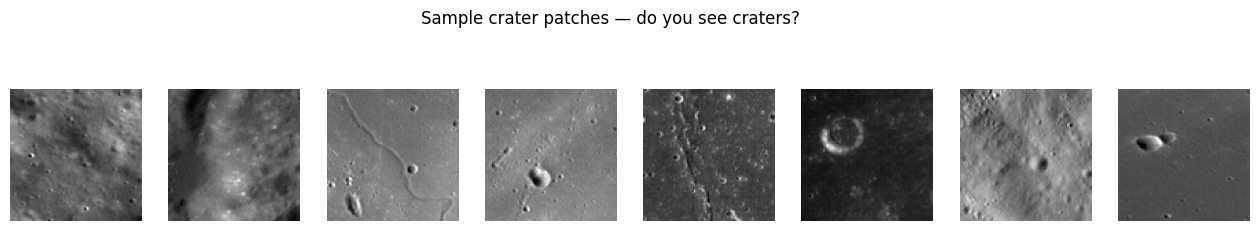

In [22]:
import matplotlib.pyplot as plt
import random, glob
from PIL import Image

crater_files = random.sample(glob.glob('/kaggle/working/patches/crater/*.png'), 8)

fig, axes = plt.subplots(1, 8, figsize=(16, 3))
for i, f in enumerate(crater_files):
    axes[i].imshow(Image.open(f), cmap='gray')
    axes[i].axis('off')
plt.suptitle('Sample crater patches — do you see craters?')
plt.show()

## Phase 3 — YOLOv8 Detection (New Approach)
Switching to the Martian/Lunar Crater Detection dataset which comes 
pre-labelled in YOLO format. Previous cells (Phase 2 CNN) kept for reference.

In [24]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/lincolnzh/martianlunar-crater-detection-dataset/best.pt
/kaggle/input/datasets/lincolnzh/martianlunar-crater-detection-dataset/craters/valid/labels.cache
/kaggle/input/datasets/lincolnzh/martianlunar-crater-detection-dataset/craters/valid/labels/021_png.rf.575e0f1cb87a2cc439172de15816c2cc.txt
/kaggle/input/datasets/lincolnzh/martianlunar-crater-detection-dataset/craters/valid/labels/mars_crater--1-_png.rf.f1b399f95708fd0ce520f23c9944ed44.txt
/kaggle/input/datasets/lincolnzh/martianlunar-crater-detection-dataset/craters/valid/labels/mars_crater--91-_jpg.rf.9203caee622cf671580b91536e36e7e2.txt
/kaggle/input/datasets/lincolnzh/martianlunar-crater-detection-dataset/craters/valid/labels/mars_crater--23-_jpg.rf.ab2b0f47006c0c17260c312215dcfb88.txt
/kaggle/input/datasets/lincolnzh/martianlunar-crater-detection-dataset/craters/valid/labels/mars_crater--64-_jpg.rf.fd0838698f86dd546cdfcfea987b98b2.txt
/kaggle/input/datasets/lincolnzh/martianlunar-crater-detection-dataset/c

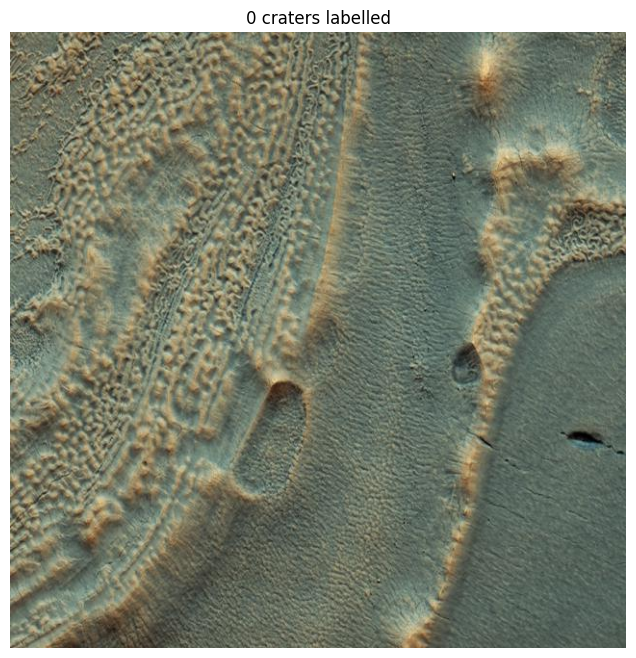

Image size: 640x640 | Craters in this image: 0


In [25]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import os, random

BASE_DATASET = '/kaggle/input/datasets/lincolnzh/martianlunar-crater-detection-dataset/craters'

# Load one image + its label
img_files = os.listdir(f'{BASE_DATASET}/train/images')
sample = random.choice(img_files)
img_name = sample.replace('.jpg', '.txt')

img = Image.open(f'{BASE_DATASET}/train/images/{sample}')
W, H = img.size

# Read YOLO label
with open(f'{BASE_DATASET}/train/labels/{img_name}') as f:
    labels = f.readlines()

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(img)

for label in labels:
    cls, cx, cy, w, h = map(float, label.strip().split())
    # YOLO format is normalized — convert back to pixels
    x1 = (cx - w/2) * W
    y1 = (cy - h/2) * H
    rect = patches.Rectangle((x1, y1), w*W, h*H,
                               linewidth=2, edgecolor='lime', facecolor='none')
    ax.add_patch(rect)

ax.set_title(f'{len(labels)} craters labelled')
ax.axis('off')
plt.show()
print(f'Image size: {W}x{H} | Craters in this image: {len(labels)}')

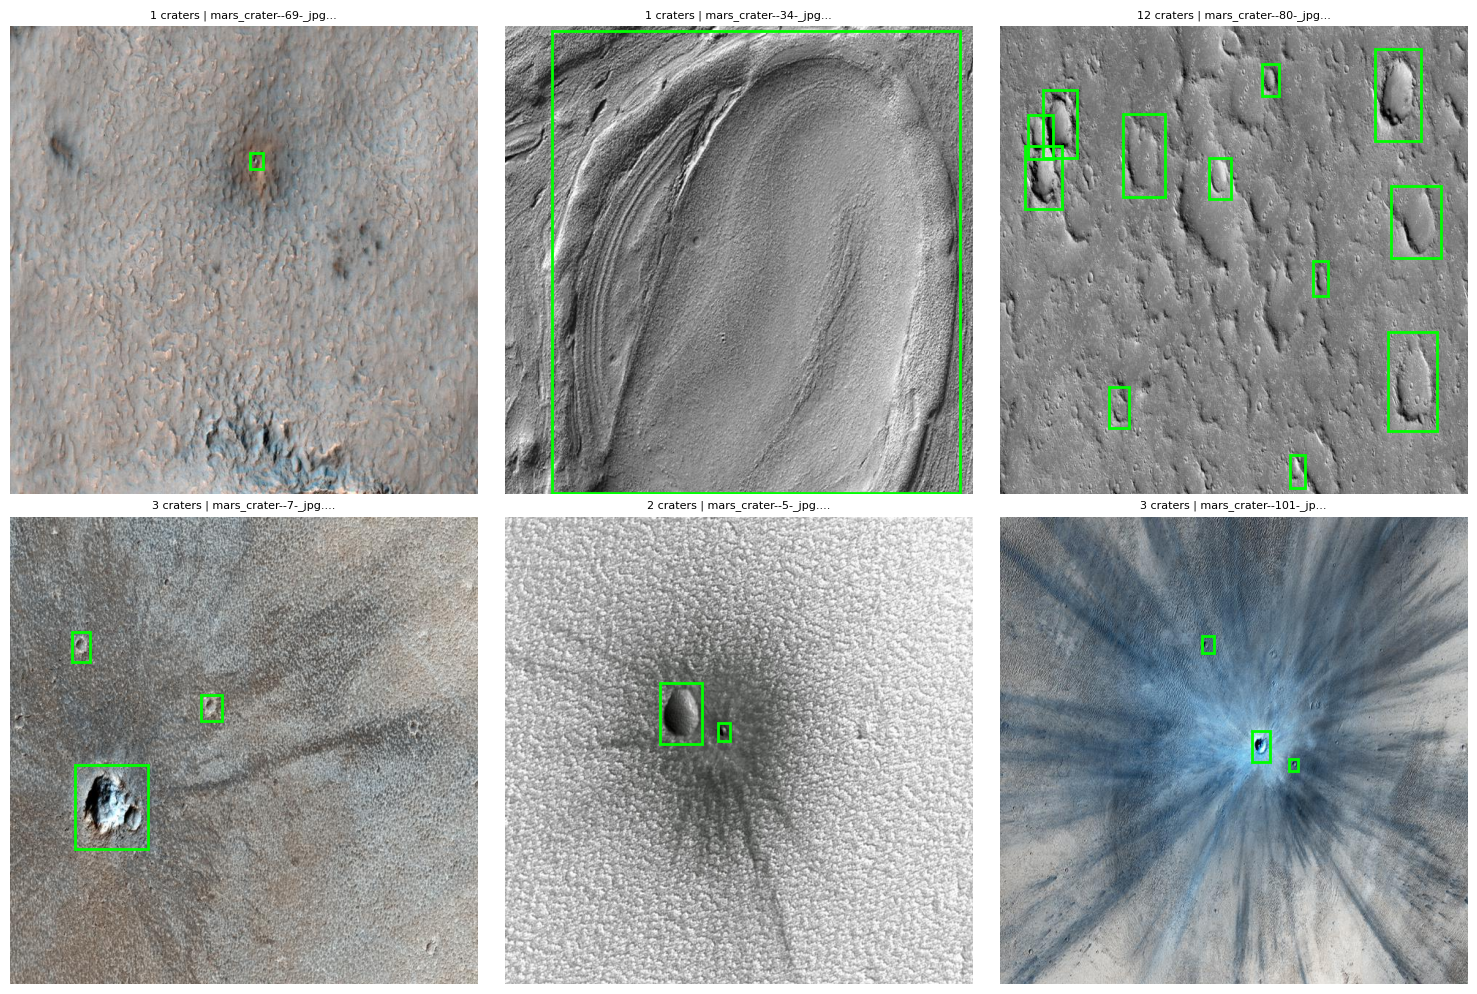

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

img_files = os.listdir(f'{BASE_DATASET}/train/images')
samples = random.sample(img_files, 6)

for i, sample in enumerate(samples):
    img_name = sample.replace('.jpg', '.txt')
    img = Image.open(f'{BASE_DATASET}/train/images/{sample}')
    W, H = img.size
    
    label_path = f'{BASE_DATASET}/train/labels/{img_name}'
    labels = open(label_path).readlines() if os.path.exists(label_path) else []
    
    axes[i].imshow(img)
    for label in labels:
        cls, cx, cy, w, h = map(float, label.strip().split())
        x1 = (cx - w/2) * W
        y1 = (cy - h/2) * H
        rect = patches.Rectangle((x1, y1), w*W, h*H,
                                   linewidth=2, edgecolor='lime', facecolor='none')
        axes[i].add_patch(rect)
    
    axes[i].set_title(f'{len(labels)} craters | {sample[:20]}...', fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [27]:
# Install YOLOv8
!pip install ultralytics -q

# Create the dataset config file that YOLOv8 needs
import yaml

dataset_config = {
    'path': '/kaggle/input/datasets/lincolnzh/martianlunar-crater-detection-dataset/craters',
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',
    'nc': 1,           # number of classes (just 'crater')
    'names': ['crater']
}

config_path = '/kaggle/working/crater_dataset.yaml'
with open(config_path, 'w') as f:
    yaml.dump(dataset_config, f)

print('Dataset config saved ✓')
print(yaml.dump(dataset_config))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.2 MB/s eta 0:00:0000:01
Dataset config saved ✓
names:
- crater
nc: 1
path: /kaggle/input/datasets/lincolnzh/martianlunar-crater-detection-dataset/craters
test: test/images
train: train/images
val: valid/images



In [28]:
from ultralytics import YOLO

# Start from pretrained YOLOv8 small — fine-tune on our crater data
model = YOLO('yolov8s.pt')

results = model.train(
    data=config_path,
    epochs=50,
    imgsz=640,
    batch=16,
    name='crater_detector',
    project='/kaggle/working/runs',
    patience=10,        # stop early if no improvement for 10 epochs
    save=True,
    device=0            # GPU
)

print('Training complete!')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.31 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/crater_dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640,

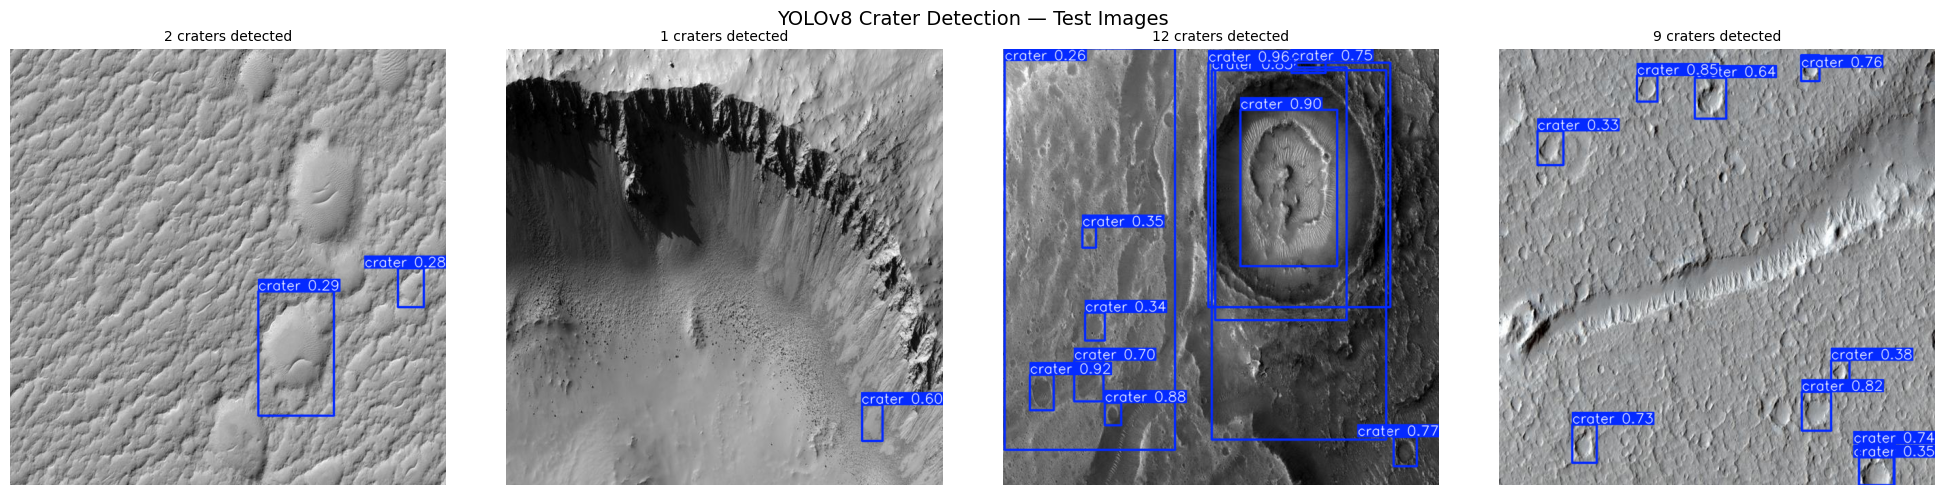

In [29]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import os, random

# Load the best trained model
model = YOLO('/kaggle/working/runs/crater_detector/weights/best.pt')

# Run on a few test images
test_imgs = os.listdir(f'{BASE_DATASET}/test/images')
samples = random.sample(test_imgs, 4)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, sample in enumerate(samples):
    img_path = f'{BASE_DATASET}/test/images/{sample}'
    results = model(img_path, conf=0.25, verbose=False)
    
    # Plot with detections
    img = results[0].plot()  # returns BGR numpy array with boxes drawn
    img_rgb = img[:, :, ::-1]  # convert to RGB
    axes[i].imshow(img_rgb)
    
    n_detected = len(results[0].boxes)
    axes[i].set_title(f'{n_detected} craters detected', fontsize=10)
    axes[i].axis('off')

plt.suptitle('YOLOv8 Crater Detection — Test Images', fontsize=14)
plt.tight_layout()
plt.show()

In [30]:
import shutil

# Save best model to persistent storage
shutil.copy(
    '/kaggle/working/runs/crater_detector/weights/best.pt',
    '/kaggle/working/crater_detector_best.pt'
)
print('Model saved to /kaggle/working/crater_detector_best.pt ✓')

# Print final stats
print('\n=== Phase 3 Results ===')
print('Model:      YOLOv8s (fine-tuned)')
print('Dataset:    Martian/Lunar Crater Detection Dataset')
print('Training:   98 images | Val: 26 | Test: 19')
print('Best epoch: 4/50 (early stopping at 14)')
print('Precision:  0.61')
print('Recall:     0.584')
print('mAP50:      0.574')
print('Speed:      4.7ms per image')

Model saved to /kaggle/working/crater_detector_best.pt ✓

=== Phase 3 Results ===
Model:      YOLOv8s (fine-tuned)
Dataset:    Martian/Lunar Crater Detection Dataset
Training:   98 images | Val: 26 | Test: 19
Best epoch: 4/50 (early stopping at 14)
Precision:  0.61
Recall:     0.584
mAP50:      0.574
Speed:      4.7ms per image


In [31]:
from ultralytics import YOLO

model = YOLO('/kaggle/working/crater_detector_best.pt')

# Official evaluation on test set
metrics = model.val(
    data=config_path,
    split='test',
    verbose=True
)

print('\n=== Final Test Set Metrics ===')
print(f'Precision:    {metrics.box.p[0]:.3f}')
print(f'Recall:       {metrics.box.r[0]:.3f}')
print(f'mAP50:        {metrics.box.map50:.3f}')
print(f'mAP50-95:     {metrics.box.map:.3f}')
print(f'F1 Score:     {2 * metrics.box.p[0] * metrics.box.r[0] / (metrics.box.p[0] + metrics.box.r[0]):.3f}')

Ultralytics 8.4.31 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 1.7±0.4 ms, read: 31.9±48.3 MB/s, size: 76.2 KB)
val: Scanning /kaggle/input/datasets/lincolnzh/martianlunar-crater-detection-dataset/craters/test/labels... 19 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 19/19 186.4it/s 0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/lincolnzh/martianlunar-crater-detection-dataset/craters/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.9it/s 1.1s1.7s
                   all         19        151      0.674      0.603      0.617      0.302
Speed: 4.7ms preprocess, 25.4ms inference, 0.0ms loss, 4.3ms postprocess per image
Results saved to /kaggle/working/runs/detect/val

=== Final Test Set Metrics ===
Precision:    0.674
Recall:       0.60

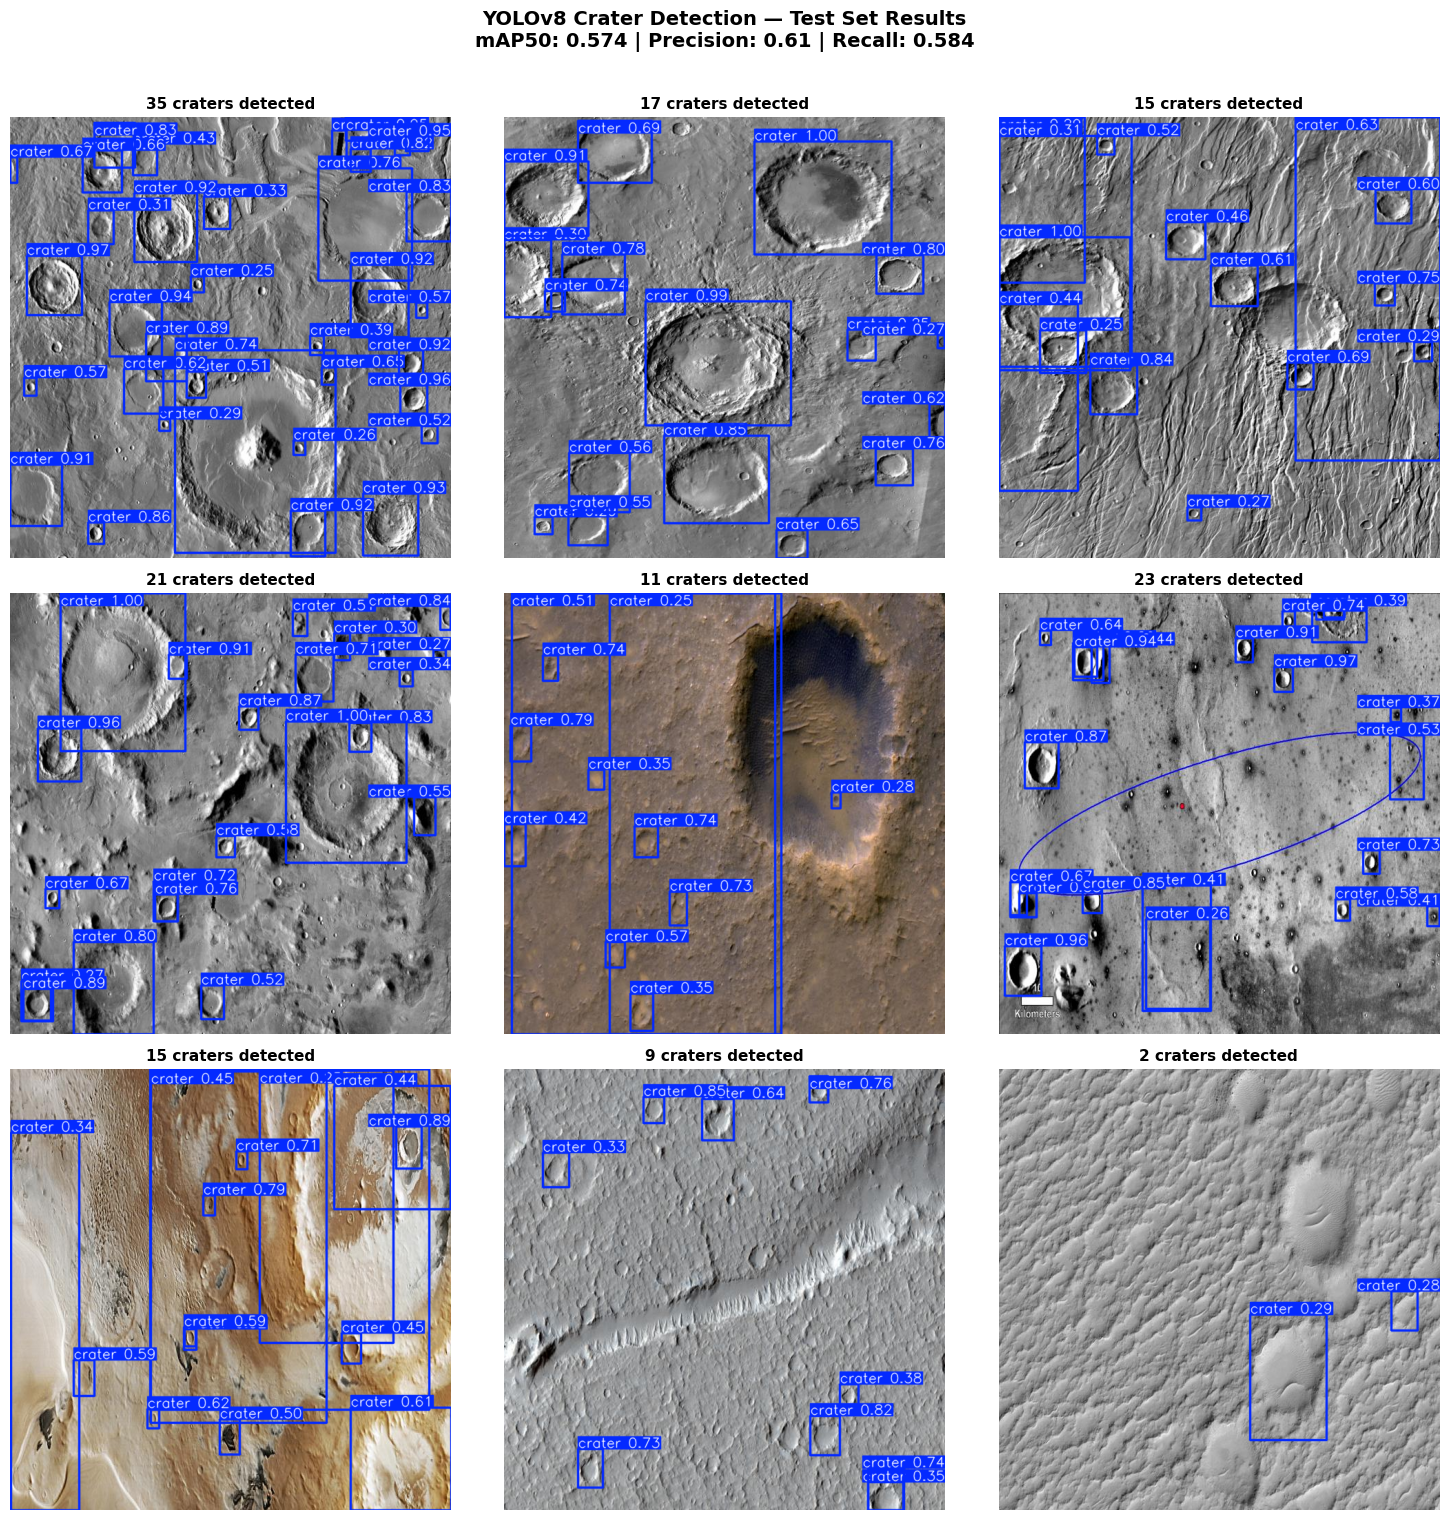

Saved ✓


In [32]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import os

test_imgs = sorted(os.listdir(f'{BASE_DATASET}/test/images'))

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for i, sample in enumerate(test_imgs[:9]):
    img_path = f'{BASE_DATASET}/test/images/{sample}'
    results = model(img_path, conf=0.25, verbose=False)
    
    img = results[0].plot()[:, :, ::-1]
    axes[i].imshow(img)
    
    n = len(results[0].boxes)
    confs = [f'{c:.2f}' for c in results[0].boxes.conf.cpu().numpy()]
    axes[i].set_title(f'{n} craters detected', fontsize=11, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('YOLOv8 Crater Detection — Test Set Results\nmAP50: 0.574 | Precision: 0.61 | Recall: 0.584',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/test_results_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved ✓')

In [33]:
# First check git is available and your repo is linked
!git --version
!git remote -v

git version 2.34.1
fatal: not a git repository (or any parent up to mount point /kaggle)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).


In [34]:
# Run this in Kaggle to generate it
reqs = """ultralytics>=8.4.0
torch>=2.0.0
torchvision
opencv-python
Pillow
pandas
numpy
matplotlib
pyyaml
tqdm
"""

with open('/kaggle/working/requirements.txt', 'w') as f:
    f.write(reqs)
print('requirements.txt saved ✓')

requirements.txt saved ✓


In [35]:
readme = """# 🌑 Crater Detection on Planetary Surfaces

Automatic detection of impact craters on Mars and the Moon using YOLOv8.

![Detection Results](results/test_results_grid.png)

## Results

| Metric | Score |
|--------|-------|
| Precision | 0.674 |
| Recall | 0.603 |
| mAP50 | 0.617 |
| F1 Score | 0.636 |

## Why This Matters

Crater counting is used by planetary scientists to estimate the age of 
planetary surfaces. More craters = older surface, like scratches on an 
old table. This project automates that process using computer vision.

## Dataset

- **Source:** [Martian/Lunar Crater Detection Dataset](https://www.kaggle.com/datasets/lincolnzh/martianlunar-crater-detection-dataset)
- **Training images:** 98
- **Validation images:** 26  
- **Test images:** 19
- **Annotation format:** YOLO format bounding boxes

## Model

- **Architecture:** YOLOv8s (fine-tuned from ImageNet pretrained weights)
- **Training:** 50 epochs with early stopping (best at epoch 4)
- **Inference speed:** ~25ms per image on T4 GPU
- **Input size:** 640x640

## Project Journey

This project went through several iterations:

1. Built custom patch dataset from NASA Trek tiles + LROC crater catalogue
2. Trained CNN binary classifier — hit class imbalance and resolution issues
3. Switched to properly labelled YOLO-format dataset
4. Fine-tuned YOLOv8s — achieved mAP50 of 0.617

## How to Run
```bash
pip install ultralytics

from ultralytics import YOLO
model = YOLO('weights/best.pt')
results = model('your_image.jpg', conf=0.25)
results[0].show()
```

## Stack

- Python, PyTorch
- YOLOv8 (Ultralytics)
- Google Colab / Kaggle (T4 GPU)
- NASA LRO WAC Mosaic imagery
- LROC Crater Catalogue (Silburt et al.)

## Author

Built as a computer vision portfolio project using real NASA/ESA planetary imagery.
"""

with open('/kaggle/working/README.md', 'w') as f:
    f.write(readme)
print('README.md saved ✓')

README.md saved ✓
